<a href="https://colab.research.google.com/github/ihlasnijam/Northstar-analytics/blob/main/Northstar_Analytics_R_in_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c('sqldf','ggplot2','dplyr','tidyr','lubridate','scales'))
library(sqldf); library(ggplot2); library(dplyr)
library(tidyr); library(lubridate); library(scales)

# Load all CSV files
customers  <- read.csv('customers.csv',  stringsAsFactors=FALSE)
orders     <- read.csv('orders.csv',     stringsAsFactors=FALSE)
deliveries <- read.csv('deliveries.csv', stringsAsFactors=FALSE)
drivers    <- read.csv('drivers.csv',    stringsAsFactors=FALSE)
vehicles   <- read.csv('vehicles.csv',   stringsAsFactors=FALSE)
hubs       <- read.csv('hubs.csv',       stringsAsFactors=FALSE)
complaints <- read.csv('complaints.csv', stringsAsFactors=FALSE)
incidents  <- read.csv('incidents.csv',  stringsAsFactors=FALSE)
app_events <- read.csv('app_events.csv', stringsAsFactors=FALSE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [4]:
# Fix inconsistent zone naming across all files
fix_zone <- function(z) {
  z <- trimws(tolower(z))
  dplyr::case_when(
    z %in% c('central','ctr','centre') ~ 'Central',
    z == 'north'                        ~ 'North',
    z == 'south'                        ~ 'South',
    z == 'east'                         ~ 'East',
    z == 'west'                         ~ 'West',
    z == 'airport'                      ~ 'Airport',
    z == 'riverside'                    ~ 'Riverside',
    TRUE ~ tools::toTitleCase(z)
  )
}
customers$home_zone    <- fix_zone(customers$home_zone)
orders$pickup_zone     <- fix_zone(orders$pickup_zone)
orders$dropoff_zone    <- fix_zone(orders$dropoff_zone)
drivers$base_zone      <- fix_zone(drivers$base_zone)
vehicles$assigned_zone <- fix_zone(vehicles$assigned_zone)

# Parse date columns
deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at          <- ymd_hms(orders$order_created_at)

# Compute actual delivery duration
deliveries$actual_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at,
           deliveries$dispatch_time, units='hours'))

cat('--- Data loaded successfully ---\n')
cat('Orders:', nrow(orders), '| Deliveries:', nrow(deliveries), '\n')
cat('Customers:', nrow(customers), '| Drivers:', nrow(drivers), '\n')
cat('Vehicles:', nrow(vehicles), '| Hubs:', nrow(hubs), '\n')
cat('Complaints:', nrow(complaints), '| Incidents:', nrow(incidents), '\n')
cat('app_events:' , nrow(app_events))


--- Data loaded successfully ---
Orders: 1250 | Deliveries: 950 
Customers: 650 | Drivers: 170 
Vehicles: 120 | Hubs: 8 
Complaints: 320 | Incidents: 280 
app_events: 640

In [14]:
# SELECT: critical priority orders from App channel
sel <- sqldf('
  SELECT order_id, customer_id, service_type,
         pickup_zone, order_value, priority_level
  FROM orders
  WHERE priority_level = \'Critical\'
    AND booking_channel = \'App\'
  ORDER BY order_value DESC
  LIMIT 8
')
cat('--- SELECT: Critical App orders ---\n');
print(sel)


ERROR: Error in parse(text = input): <text>:6:27: unexpected symbol
5:   FROM orders
6:   WHERE priority_level = 'Critical
                             ^


In [18]:
# INSERT: add a test complaint record
new_row <- data.frame(
  complaint_id='CP_TEST', customer_id='C0001',
  order_id='O00001', complaint_type='Delay',
  channel='App', severity='High',
  created_at='2025-01-01 09:00:00',
  status='Open', resolution_days=NA,
  compensation_amount=NA)
complaints <- rbind(complaints, new_row)
cat('--- INSERT: complaints now has', nrow(complaints), 'rows ---\n')

# Verify the inserted row
print(sqldf("SELECT * FROM complaints WHERE complaint_id = 'CP_TEST'"))

--- INSERT: complaints now has 321 rows ---
  complaint_id customer_id order_id complaint_type channel severity
1      CP_TEST       C0001   O00001          Delay     App     High
           created_at status resolution_days compensation_amount
1 2025-01-01 09:00:00   Open              NA                  NA


In [10]:
# UPDATE: escalate long-running open complaints to Critical severity
complaints <- complaints %>%
  mutate(severity = case_when(
    status == 'Open' &
    !is.na(resolution_days) &
    resolution_days > 10 ~ 'Critical',
    TRUE ~ severity
  ))

cat('--- UPDATE result: severity distribution after escalation ---\n')
print(table(complaints$severity))

--- UPDATE result: severity distribution after escalation ---

Critical     High      Low   Medium 
      35       62       63      161 


In [13]:
# DELETE: remove test record
complaints <- complaints[complaints$complaint_id != 'CP_TEST', ]
cat('\n--- DELETE: complaints after deletion:', nrow(complaints), 'rows ---\n')



--- DELETE: complaints after deletion: 320 rows ---


In [26]:
# Delivery performance summary by status
summary <- sqldf('
  SELECT delivery_status,
    COUNT(*)                                   AS total,
    ROUND(AVG(route_distance_km), 2)           AS avg_dist_km,
    ROUND(AVG(fuel_or_charge_cost), 2)         AS avg_cost,
    ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating,
    SUM(manual_route_override_count)           AS total_overrides
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
')
print(summary)

# Cost per km and override rate by status
cost <-  sqldf('
  SELECT delivery_status,
    ROUND(SUM(fuel_or_charge_cost)/SUM(route_distance_km),3) AS cost_per_km,
    ROUND(100.0 * SUM(CASE WHEN manual_route_override_count > 0
          THEN 1 ELSE 0 END) / COUNT(*), 1) AS override_rate_pct
  FROM deliveries
  GROUP BY delivery_status
')
print(cost)


  delivery_status total avg_dist_km avg_cost avg_rating total_overrides
1          OnTime   616       13.78    12.68       4.28             567
2         Delayed   202       14.67    13.14       3.11             217
3          Failed   132       13.37    13.15       3.05             137
  delivery_status cost_per_km override_rate_pct
1         Delayed       0.896              61.4
2          Failed       0.984              65.2
3          OnTime       0.920              55.4


In [24]:
# Which zones have the worst delivery performance?
zones <- sqldf('
  SELECT o.pickup_zone,
    COUNT(d.delivery_id)  AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = \'Failed\'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = \'Delayed\' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status
          IN (\'Failed\',\'Delayed\')
          THEN 1 ELSE 0 END) / COUNT(*), 1) AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
')
print(zones)


  pickup_zone total_deliveries failed delayed failure_rate_pct avg_cost
1     Central              174     33      51             48.3    12.12
2     Airport              113     12      31             38.1    17.08
3   Riverside              119     18      25             36.1    12.39
4        East              156     19      31             32.1    12.57
5       North              135     22      21             31.9    12.07
6        West              114     14      21             30.7    11.94
7       South              139     14      22             25.9    12.48


In [27]:
# Top 10 drivers by failure rate
drivers <- sqldf('
  SELECT d.driver_id, dr.employment_type, dr.base_zone,
    ROUND(dr.training_score, 1)  AS training_score,
    ROUND(dr.driver_rating, 2)   AS driver_rating,
    COUNT(d.delivery_id)         AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = \'Failed\'
        THEN 1 ELSE 0 END)       AS failures,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = \'Failed\'
          THEN 1 ELSE 0 END) / COUNT(*), 1) AS failure_rate_pct,
    SUM(d.manual_route_override_count) AS total_overrides
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 5
  ORDER BY failure_rate_pct DESC
  LIMIT 10
')
print(drivers)


   driver_id employment_type base_zone training_score driver_rating
1       D092        FullTime      East           88.2          4.24
2       D104        FullTime      West           87.7          3.45
3       D024        PartTime Riverside           71.4          3.35
4       D010        FullTime      West           70.0          3.95
5       D144        FullTime      West           85.0          3.83
6       D143        FullTime   Central           68.5          4.14
7       D095        FullTime      West           99.0          3.15
8       D005        FullTime     North           69.7          4.14
9       D165        PartTime     North           82.2          3.89
10      D133        Contract     South           88.2          3.99
   total_deliveries failures failure_rate_pct total_overrides
1                 5        3             60.0               2
2                 7        4             57.1              12
3                 8        4             50.0               9
4   

In [28]:
# Complaint volume and compensation cost by type
comp_volume <- sqldf('
  SELECT complaint_type,
    COUNT(*)                           AS total_complaints,
    SUM(CASE WHEN severity=\'High\'
        THEN 1 ELSE 0 END)             AS high_severity,
    ROUND(AVG(resolution_days), 1)     AS avg_resolution_days,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation,
    ROUND(SUM(compensation_amount), 2) AS total_compensation
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
')
print(comp_volume)

     complaint_type total_complaints high_severity avg_resolution_days
1             Delay              102            13                 7.3
2      MissedPickup               64            16                 7.6
3          AppIssue               53            10                 8.6
4   DriverBehaviour               51            12                 8.2
5 SupportExperience               20             3                 7.5
6           Billing               16             4                 7.8
7            Damage               15             4                11.3
  avg_compensation total_compensation
1            18.05            1696.84
2            22.59            1423.40
3            19.61             980.72
4            21.15             973.06
5            17.13             342.50
6            23.87             381.94
7            23.98             359.73


In [29]:
# Customers with repeated complaints
repeated_complaints <-sqldf('
  SELECT c.customer_id, cu.customer_type, cu.home_zone,
    COUNT(c.complaint_id)  AS total_complaints,
    SUM(CASE WHEN c.severity = \'High\'
        THEN 1 ELSE 0 END) AS high_sev_count,
    ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation_paid
  FROM complaints c
  JOIN customers cu ON c.customer_id = cu.customer_id
  GROUP BY c.customer_id
  HAVING total_complaints >= 2
  ORDER BY total_complaints DESC, total_compensation_paid DESC
  LIMIT 15
')
print(repeated_complaints)

   customer_id customer_type home_zone total_complaints high_sev_count
1        C0368      Consumer     North                4              1
2        C0421      Consumer   Central                3              2
3        C0573           SME   Airport                3              2
4        C0242      Consumer      East                3              1
5        C0282      Consumer Riverside                3              0
6        C0545      Consumer     South                3              0
7        C0372      Consumer      West                3              1
8        C0191      Consumer     North                3              0
9        C0172      Consumer     North                3              1
10       C0142      Consumer     South                3              1
11       C0110      Consumer      East                3              1
12       C0001           SME     North                3              2
13       C0626      Consumer     South                3              1
14    

In [30]:
# vehicle condition  and failure rate
vehicle <- sqldf('
  SELECT v.vehicle_type, v.maintenance_status,
    COUNT(d.delivery_id)                   AS total_deliveries,
    ROUND(AVG(v.battery_health_pct), 1)    AS avg_battery_health,
    ROUND(AVG(d.fuel_or_charge_cost), 2)   AS avg_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    SUM(CASE WHEN d.delivery_status=\'Failed\'
        THEN 1 ELSE 0 END)                 AS failures
  FROM deliveries d
  JOIN vehicles v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.vehicle_type, v.maintenance_status
  ORDER BY v.vehicle_type, failures DESC
')
print(vehicle)

   vehicle_type maintenance_status total_deliveries avg_battery_health avg_cost
1      CargoVan           InRepair               68               69.8    12.46
2      CargoVan             Active              117               74.4    13.37
3      CargoVan          Scheduled               38               69.0    11.88
4        Diesel           InRepair               55               75.7    13.30
5        Diesel             Active               80               67.0    12.43
6        Diesel          Scheduled                9               81.3    13.93
7            EV           InRepair               60               77.8    12.78
8            EV             Active              214               83.0    12.98
9            EV          Scheduled               65               82.9    12.88
10       Hybrid           InRepair               71               83.3    13.13
11       Hybrid             Active              131               73.7    12.51
12       Hybrid          Scheduled      

In [31]:
hub_perf <- sqldf('
  SELECT h.hub_name, h.zone, h.hub_type, h.capacity_score,
    COUNT(d.delivery_id)  AS total_dispatched,
    SUM(CASE WHEN d.delivery_status=\'Failed\'
        THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status=\'Delayed\'
        THEN 1 ELSE 0 END) AS delayed,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_dispatch_cost
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id
  ORDER BY failed DESC
')
print(hub_perf)


        hub_name      zone  hub_type capacity_score total_dispatched failed
1  Midtown Relay   Central  Charging             63              128     26
2   Central Core   Central   Control             88              115     23
3 North Exchange     North  Dispatch             82              136     17
4      West Gate      West  Dispatch             69              127     16
5    Airport Hub   Airport  Dispatch             71              104     15
6  Riverside Hub Riverside Warehouse             66              115     14
7      East Dock      East Warehouse             74              119     11
8     South Link     South  Dispatch             78              106     10
  delayed avg_dispatch_cost
1      22             11.71
2      25             13.69
3      26             12.76
4      28             13.17
5      27             13.32
6      25             12.92
7      23             12.74
8      26             12.57


In [34]:
# Build merged operational dataset
ops <- deliveries %>%
  left_join(orders,   by='order_id') %>%
  left_join(drivers,  by='driver_id') %>%
  left_join(vehicles, by='vehicle_id') %>%
  left_join(hubs,     by='hub_id')

# Feature engineering with mutate()
ops <- ops %>%
  mutate(
    delay_hours  = actual_hours - promised_window_hours,
    is_failed    = ifelse(delivery_status == 'Failed', 1, 0),
    has_override = ifelse(manual_route_override_count > 0, 1, 0),
    cost_per_km  = ifelse(route_distance_km > 0,
                          fuel_or_charge_cost / route_distance_km, NA)
  )

# Zone performance summary using group_by + summarise
zone_perf <- ops %>%
  group_by(pickup_zone) %>%
  summarise(
    total        = n(),
    failure_rate = round(mean(is_failed, na.rm=TRUE) * 100, 1),
    avg_delay  = round(mean(delay_hours[delay_hours>0], na.rm=TRUE), 2),
    avg_cost_km  = round(mean(cost_per_km, na.rm=TRUE), 3),
    override_pct = round(mean(has_override, na.rm=TRUE) * 100, 1)
  ) %>% arrange(desc(failure_rate))
cat('--- Zone performance summary ---\n')
print(zone_perf)

# Impute missing training scores with median
ops$training_score[is.na(ops$training_score)] <-
  median(ops$training_score, na.rm=TRUE)
cat('\nMissing training scores imputed. Remaining NAs:',
    sum(is.na(ops$training_score)), '\n')


--- Zone performance summary ---
# A tibble: 7 × 6
  pickup_zone total failure_rate avg_delay avg_cost_km override_pct
  <chr>       <int>        <dbl>     <dbl>       <dbl>        <dbl>
1 Central       174         19        7.48       1.32          67.2
2 North         135         16.3      6.14       1.34          47.4
3 Riverside     119         15.1      7.56       1.42          48.7
4 West          114         12.3      6          1.25          56.1
5 East          156         12.2      5.33       1.36          52.6
6 Airport       113         10.6      5.87       0.616         84.1
7 South         139         10.1      5.85       1.40          51.1

Missing training scores imputed. Remaining NAs: 0 


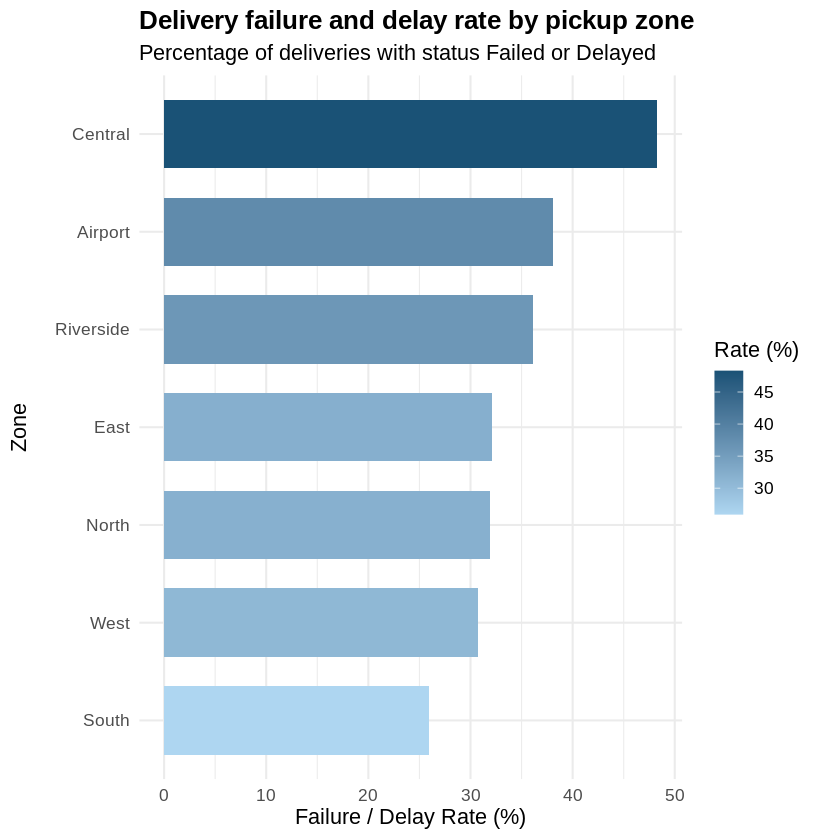

In [36]:
zone_summary <- sqldf('
  SELECT o.pickup_zone AS zone,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status
          IN (\'Failed\',\'Delayed\')
          THEN 1 ELSE 0 END) / COUNT(*), 1) AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
')

ggplot(zone_summary,
       aes(x=reorder(zone,failure_rate_pct),
           y=failure_rate_pct, fill=failure_rate_pct)) +
  geom_col(width=0.7) +
  coord_flip() +
  scale_fill_gradient(low='#AED6F1', high='#1A5276') +
  labs(title='Delivery failure and delay rate by pickup zone',
       subtitle='Percentage of deliveries with status Failed or Delayed',
       x='Zone', y='Failure / Delay Rate (%)', fill='Rate (%)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))


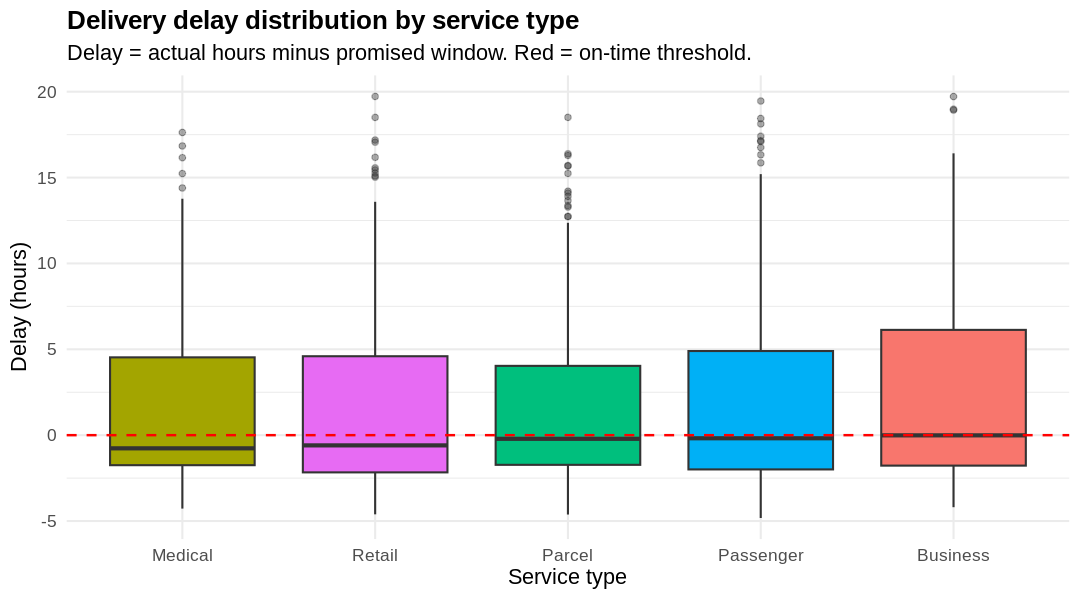

In [38]:
delay_data <- ops %>%
  filter(!is.na(delay_hours), delay_hours > -5, delay_hours < 50)

ggplot(delay_data,
       aes(x=reorder(service_type, delay_hours, median),
           y=delay_hours, fill=service_type)) +
  geom_boxplot(outlier.alpha=0.4, outlier.size=1.5) +
  geom_hline(yintercept=0, linetype='dashed',
             colour='red', linewidth=0.7) +
  labs(title='Delivery delay distribution by service type',
       subtitle='Delay = actual hours minus promised window. Red = on-time threshold.',
       x='Service type', y='Delay (hours)') +
  theme_minimal(base_size=13) +
  theme(legend.position='none',
        plot.title=element_text(face='bold'))


`geom_smooth()` using formula = 'y ~ x'
Warning message in qt((1 - level)/2, df):
“NaNs produced”
Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


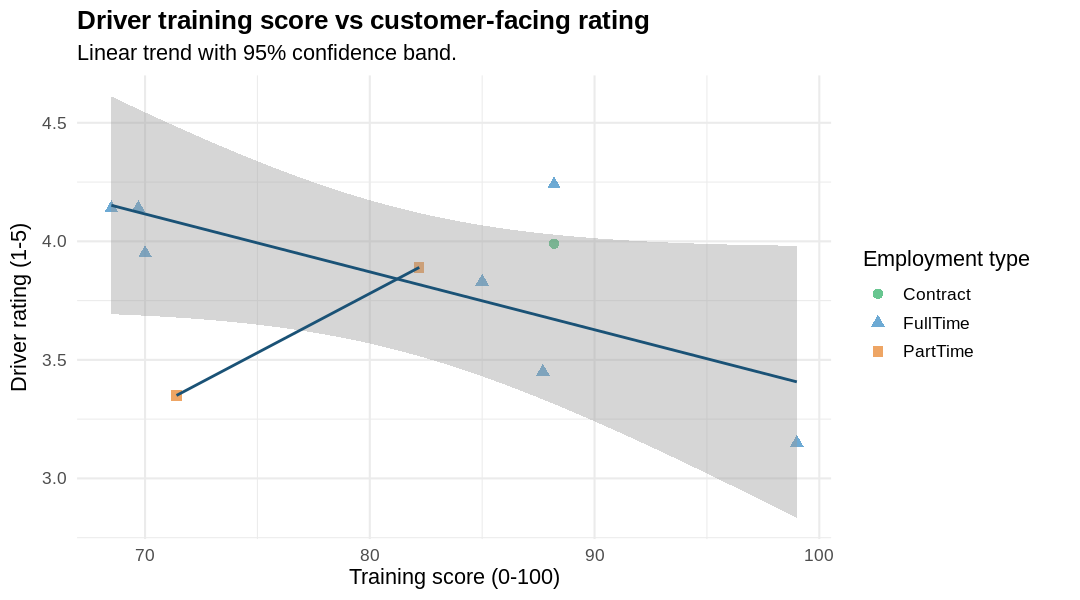

In [39]:
ggplot(drivers,
       aes(x=training_score, y=driver_rating,
           colour=employment_type, shape=employment_type)) +
  geom_point(alpha=0.7, size=2.5) +
  geom_smooth(method='lm', se=TRUE, linewidth=0.8, colour='#1A5276') +
  scale_colour_manual(values=c('FullTime'='#2E86C1',
                               'PartTime'='#E67E22',
                               'Contract'='#27AE60')) +
  labs(title='Driver training score vs customer-facing rating',
       subtitle='Linear trend with 95% confidence band.',
       x='Training score (0-100)', y='Driver rating (1-5)',
       colour='Employment type', shape='Employment type') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))
